<a href="https://colab.research.google.com/github/ilsagandeguay/PCVK-Ganjil-2026/blob/main/Week5_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Ilsa Alziza Khan Gandeguay'
NIM  = '26410702007'

N     = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L' : 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Ilsa Alziza Khan Gandeguay
NIM    : 26410702007 | N = 7
bins   : 64
clip   : 2.0
tile   : 5
L      : 4
WAKTU  : 2026-09-29 19:30:46 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : b4f7a74c73cafd3d


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import skimage.io as io
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import glob

BASE = '/content/drive/MyDrive/Politeknik Negeri Malang/Matakuliah/Pengenalan Citra dan Visi Komputer/Week5/Images/'

print('BASE   :', BASE)
print('Folder pribadi tersedia:', os.path.exists(BASE))

BASE   : /content/drive/MyDrive/Politeknik Negeri Malang/Matakuliah/Pengenalan Citra dan Visi Komputer/Week5/Images/
Folder pribadi tersedia: True


In [ ]:
# Deklarasi Citra Yang Digunakan
files = ['KTP1a.jpg', 'KTP1b.jpg', 'KTP1c.jpg', 'KTP1d.jpg']
lena = ['lena.jpg', 'lena_lc.jpg']


# E-1 PERCOBAAN HISTOGRAM

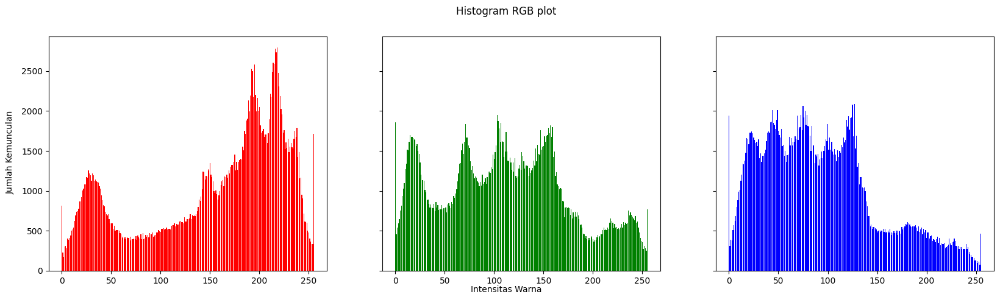

In [ ]:
# E-1.1 Tahap 1 — lena.jpg
img = cv.imread(BASE + 'lena.jpg', )
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names                = np.arange(256)

red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img [y][x][0]] += 1
    green[img [y][x][1]] += 1
    blue[img [y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

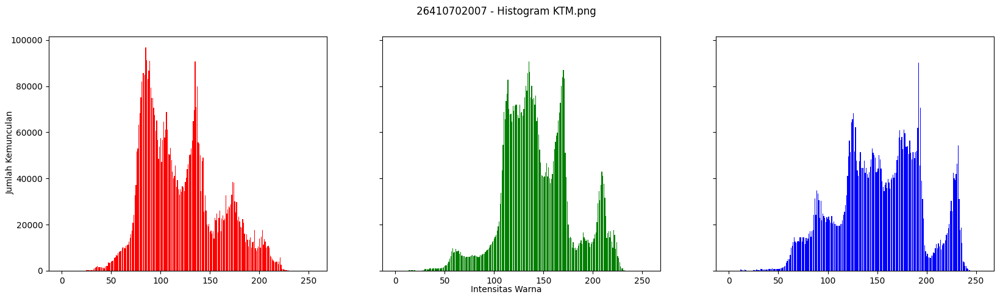

In [ ]:
# E-1.1 Tahap 2 — KTM.png
img2 = cv.imread(BASE + files[1])
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img2)
names                = np.arange(256)

red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img2 [y][x][0]] += 1
    green[img2 [y][x][1]] += 1
    blue[img2 [y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram KTM.png')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

### **Pertanyaan Praktikum E-1.1**

## Tahap 1. Lena.jpg

=== HASIL PERBANDINGAN LENA.JPG ===
Selisih maksimum cv.calcHist vs np.histogram : 0
Selisih maksimum cv.calcHist vs manual      : 0
Selisih maksimum np.histogram vs manual     : 0
------------------------------------------------
Selisih maksimum keseluruhan                 : 0
✓ HASIL: Ketiga histogram SAMA PERSIS.


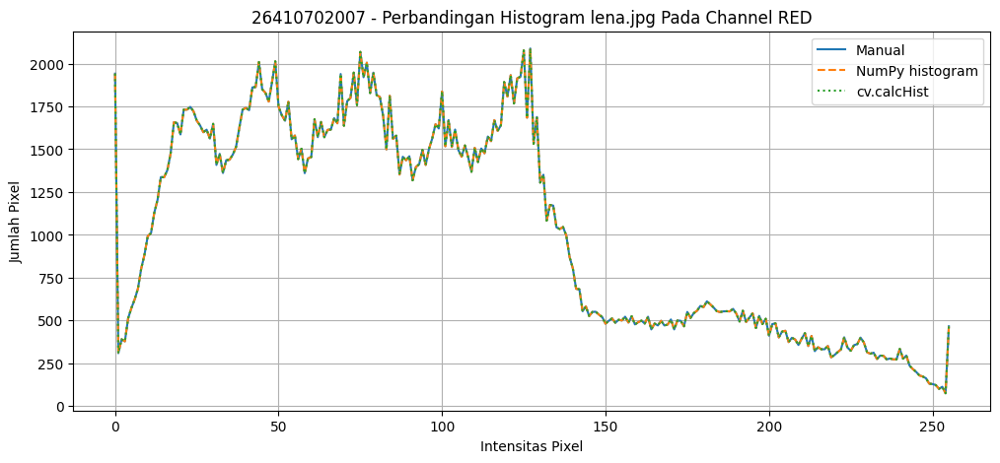

In [ ]:
# Membaca citra
img_e1 = cv.imread(BASE + 'lena.jpg')
img_e1 = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Mengambil channel R
channel = img_e1[:, :, 0]

# 1. Histogram menggunakan cv.calcHist
hist_cv = cv.calcHist(
    [channel],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

# 2. Histogram menggunakan numpy.histogram
hist_np, bins = np.histogram(
    channel.ravel(),
    bins=256,
    range=(0, 256)
)

# 3. Histogram manual menggunakan NumPy
hist_manual = np.zeros(256, dtype=np.int64)

for nilai in channel.ravel():
    hist_manual[nilai] += 1

# Menghitung selisih maksimum
selisih_cv_np = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_np)
)

selisih_cv_manual = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_manual)
)

selisih_np_manual = np.max(
    np.abs(hist_np - hist_manual)
)

selisih_maksimum = max(
    selisih_cv_np,
    selisih_cv_manual,
    selisih_np_manual
)

print("=== HASIL PERBANDINGAN LENA.JPG ===")
print("Selisih maksimum cv.calcHist vs np.histogram :", selisih_cv_np)
print("Selisih maksimum cv.calcHist vs manual      :", selisih_cv_manual)
print("Selisih maksimum np.histogram vs manual     :", selisih_np_manual)
print("------------------------------------------------")
print("Selisih maksimum keseluruhan                 :", selisih_maksimum)

if selisih_maksimum == 0:
    print("✓ HASIL: Ketiga histogram SAMA PERSIS.")
else:
    print("✗ HASIL: Terdapat perbedaan pada histogram.")

# Menampilkan histogram
plt.figure(figsize=(12, 5))

plt.plot(hist_manual, label='Manual')
plt.plot(hist_np, '--', label='NumPy histogram')
plt.plot(hist_cv, ':', label='cv.calcHist')

plt.title(NIM + ' - Perbandingan Histogram lena.jpg Pada Channel RED')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.legend()
plt.grid()
plt.show()

=== HASIL PERBANDINGAN LENA.JPG ===
Selisih maksimum cv.calcHist vs np.histogram : 0
Selisih maksimum cv.calcHist vs manual      : 0
Selisih maksimum np.histogram vs manual     : 0
------------------------------------------------
Selisih maksimum keseluruhan                 : 0
✓ HASIL: Ketiga histogram SAMA PERSIS.


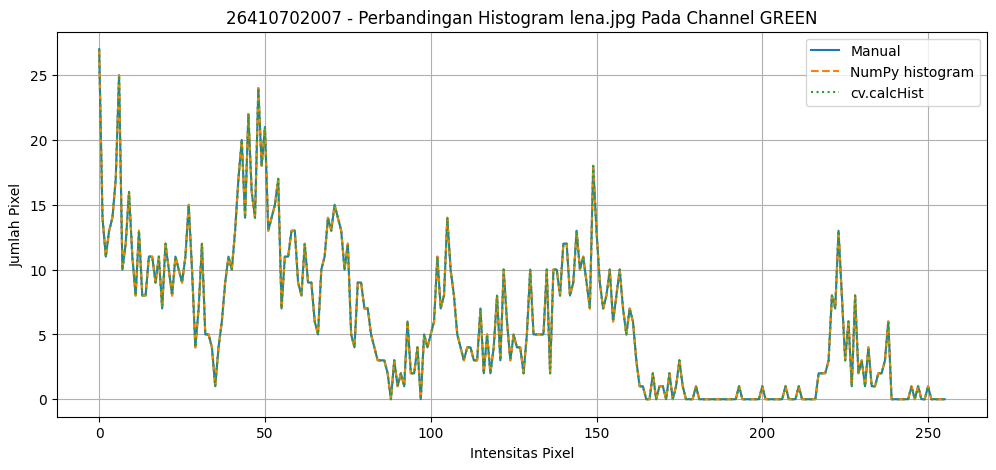

In [ ]:
# Mengambil channel G
channel = img_e1[:, 0, :]

# 1. Histogram menggunakan cv.calcHist
hist_cv = cv.calcHist(
    [channel],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

# 2. Histogram menggunakan numpy.histogram
hist_np, bins = np.histogram(
    channel.ravel(),
    bins=256,
    range=(0, 256)
)

# 3. Histogram manual menggunakan NumPy
hist_manual = np.zeros(256, dtype=np.int64)

for nilai in channel.ravel():
    hist_manual[nilai] += 1

# Menghitung selisih maksimum
selisih_cv_np = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_np)
)

selisih_cv_manual = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_manual)
)

selisih_np_manual = np.max(
    np.abs(hist_np - hist_manual)
)

selisih_maksimum = max(
    selisih_cv_np,
    selisih_cv_manual,
    selisih_np_manual
)

print("=== HASIL PERBANDINGAN LENA.JPG ===")
print("Selisih maksimum cv.calcHist vs np.histogram :", selisih_cv_np)
print("Selisih maksimum cv.calcHist vs manual      :", selisih_cv_manual)
print("Selisih maksimum np.histogram vs manual     :", selisih_np_manual)
print("------------------------------------------------")
print("Selisih maksimum keseluruhan                 :", selisih_maksimum)

if selisih_maksimum == 0:
    print("✓ HASIL: Ketiga histogram SAMA PERSIS.")
else:
    print("✗ HASIL: Terdapat perbedaan pada histogram.")

# Menampilkan histogram
plt.figure(figsize=(12, 5))

plt.plot(hist_manual, label='Manual')
plt.plot(hist_np, '--', label='NumPy histogram')
plt.plot(hist_cv, ':', label='cv.calcHist')

plt.title(NIM + ' - Perbandingan Histogram lena.jpg Pada Channel GREEN')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.legend()
plt.grid()
plt.show()

=== HASIL PERBANDINGAN LENA.JPG ===
Selisih maksimum cv.calcHist vs np.histogram : 0
Selisih maksimum cv.calcHist vs manual      : 0
Selisih maksimum np.histogram vs manual     : 0
------------------------------------------------
Selisih maksimum keseluruhan                 : 0
✓ HASIL: Ketiga histogram SAMA PERSIS.


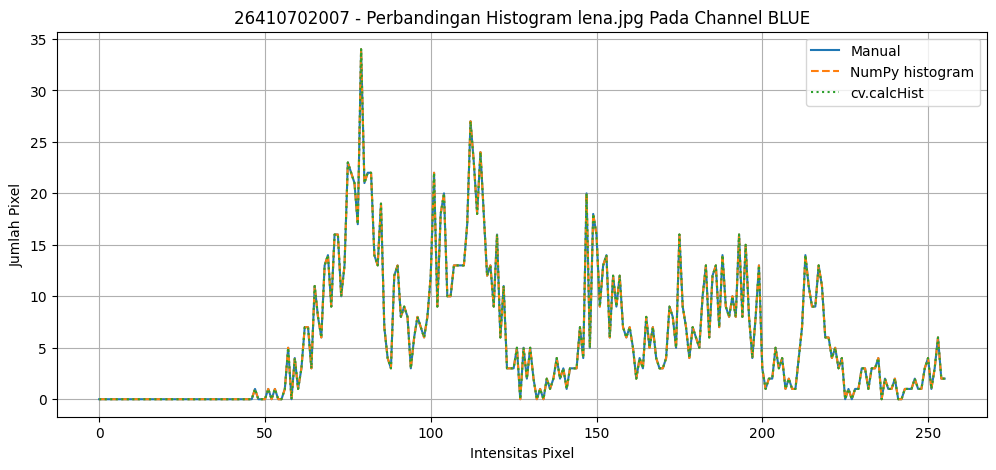

In [ ]:
# Mengambil channel B
channel = img_e1[0, :, :]

# 1. Histogram menggunakan cv.calcHist
hist_cv = cv.calcHist(
    [channel],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

# 2. Histogram menggunakan numpy.histogram
hist_np, bins = np.histogram(
    channel.ravel(),
    bins=256,
    range=(0, 256)
)

# 3. Histogram manual menggunakan NumPy
hist_manual = np.zeros(256, dtype=np.int64)

for nilai in channel.ravel():
    hist_manual[nilai] += 1

# Menghitung selisih maksimum
selisih_cv_np = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_np)
)

selisih_cv_manual = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_manual)
)

selisih_np_manual = np.max(
    np.abs(hist_np - hist_manual)
)

selisih_maksimum = max(
    selisih_cv_np,
    selisih_cv_manual,
    selisih_np_manual
)

print("=== HASIL PERBANDINGAN LENA.JPG ===")
print("Selisih maksimum cv.calcHist vs np.histogram :", selisih_cv_np)
print("Selisih maksimum cv.calcHist vs manual      :", selisih_cv_manual)
print("Selisih maksimum np.histogram vs manual     :", selisih_np_manual)
print("------------------------------------------------")
print("Selisih maksimum keseluruhan                 :", selisih_maksimum)

if selisih_maksimum == 0:
    print("✓ HASIL: Ketiga histogram SAMA PERSIS.")
else:
    print("✗ HASIL: Terdapat perbedaan pada histogram.")

# Menampilkan histogram
plt.figure(figsize=(12, 5))

plt.plot(hist_manual, label='Manual')
plt.plot(hist_np, '--', label='NumPy histogram')
plt.plot(hist_cv, ':', label='cv.calcHist')

plt.title(NIM + ' - Perbandingan Histogram lena.jpg Pada Channel BLUE')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.legend()
plt.grid()
plt.show()

## Tahap 2. KTP 1b.jpg

=== HASIL PERBANDINGAN KTP1b.JPG ===
Selisih maksimum cv.calcHist vs np.histogram : 0
Selisih maksimum cv.calcHist vs manual       : 0
Selisih maksimum np.histogram vs manual      : 0
------------------------------------------------
Selisih maksimum keseluruhan                 : 0
✓ HASIL: Ketiga histogram SAMA PERSIS.


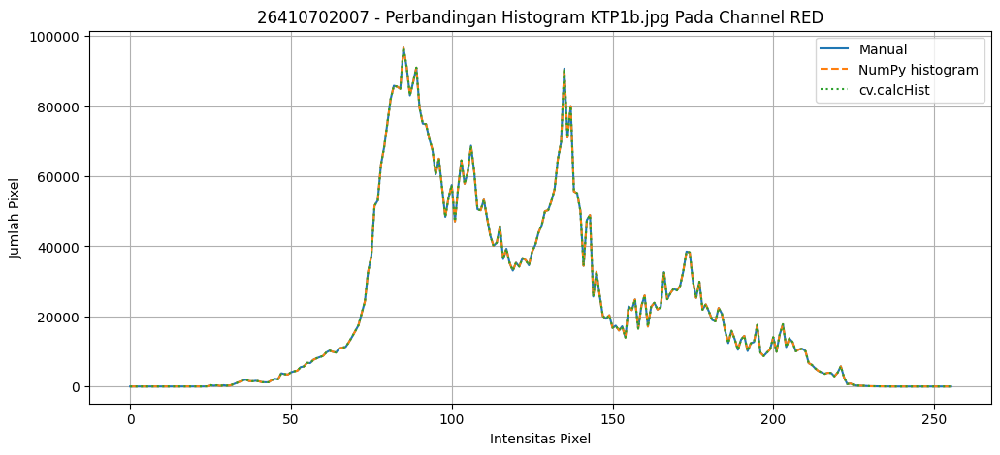

In [ ]:
# Membaca citra
img1 = cv.imread(BASE + files[1])
img_e1T2 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)

# Mengambil channel R
channel = img_e1T2[:, :, 0]

# 1. Histogram menggunakan cv.calcHist
hist_cv = cv.calcHist(
    [channel],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

# 2. Histogram menggunakan numpy.histogram
hist_np, bins = np.histogram(
    channel.ravel(),
    bins=256,
    range=(0, 256)
)

# 3. Histogram manual menggunakan NumPy
hist_manual = np.zeros(256, dtype=np.int64)

for nilai in channel.ravel():
    hist_manual[nilai] += 1

# Menghitung selisih maksimum
selisih_cv_np = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_np)
)

selisih_cv_manual = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_manual)
)

selisih_np_manual = np.max(
    np.abs(hist_np - hist_manual)
)

selisih_maksimum = max(
    selisih_cv_np,
    selisih_cv_manual,
    selisih_np_manual
)

print("=== HASIL PERBANDINGAN KTP1b.JPG ===")
print("Selisih maksimum cv.calcHist vs np.histogram :", selisih_cv_np)
print("Selisih maksimum cv.calcHist vs manual       :", selisih_cv_manual)
print("Selisih maksimum np.histogram vs manual      :", selisih_np_manual)
print("------------------------------------------------")
print("Selisih maksimum keseluruhan                 :", selisih_maksimum)

if selisih_maksimum == 0:
    print("✓ HASIL: Ketiga histogram SAMA PERSIS.")
else:
    print("✗ HASIL: Terdapat perbedaan pada histogram.")

# Menampilkan histogram
plt.figure(figsize=(12, 5))

plt.plot(hist_manual, label='Manual')
plt.plot(hist_np, '--', label='NumPy histogram')
plt.plot(hist_cv, ':', label='cv.calcHist')

plt.title(NIM + ' - Perbandingan Histogram KTP1b.jpg Pada Channel RED')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.legend()
plt.grid()
plt.show()

=== HASIL PERBANDINGAN KTP1b.JPG ===
Selisih maksimum cv.calcHist vs np.histogram : 0
Selisih maksimum cv.calcHist vs manual       : 0
Selisih maksimum np.histogram vs manual      : 0
------------------------------------------------
Selisih maksimum keseluruhan                 : 0
✓ HASIL: Ketiga histogram SAMA PERSIS.


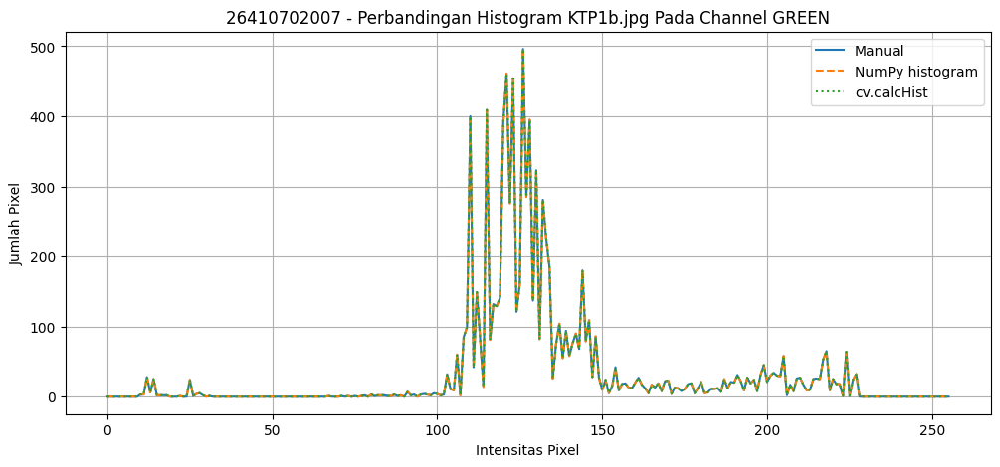

In [ ]:
# Mengambil channel G
channel = img_e1T2[:, 0, :]

# 1. Histogram menggunakan cv.calcHist
hist_cv = cv.calcHist(
    [channel],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

# 2. Histogram menggunakan numpy.histogram
hist_np, bins = np.histogram(
    channel.ravel(),
    bins=256,
    range=(0, 256)
)

# 3. Histogram manual menggunakan NumPy
hist_manual = np.zeros(256, dtype=np.int64)

for nilai in channel.ravel():
    hist_manual[nilai] += 1

# Menghitung selisih maksimum
selisih_cv_np = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_np)
)

selisih_cv_manual = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_manual)
)

selisih_np_manual = np.max(
    np.abs(hist_np - hist_manual)
)

selisih_maksimum = max(
    selisih_cv_np,
    selisih_cv_manual,
    selisih_np_manual
)

print("=== HASIL PERBANDINGAN KTP1b.JPG ===")
print("Selisih maksimum cv.calcHist vs np.histogram :", selisih_cv_np)
print("Selisih maksimum cv.calcHist vs manual       :", selisih_cv_manual)
print("Selisih maksimum np.histogram vs manual      :", selisih_np_manual)
print("------------------------------------------------")
print("Selisih maksimum keseluruhan                 :", selisih_maksimum)

if selisih_maksimum == 0:
    print("✓ HASIL: Ketiga histogram SAMA PERSIS.")
else:
    print("✗ HASIL: Terdapat perbedaan pada histogram.")

# Menampilkan histogram
plt.figure(figsize=(12, 5))

plt.plot(hist_manual, label='Manual')
plt.plot(hist_np, '--', label='NumPy histogram')
plt.plot(hist_cv, ':', label='cv.calcHist')

plt.title(NIM + ' - Perbandingan Histogram KTP1b.jpg Pada Channel GREEN')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.legend()
plt.grid()
plt.show()

=== HASIL PERBANDINGAN KTP1b.JPG ===
Selisih maksimum cv.calcHist vs np.histogram : 0
Selisih maksimum cv.calcHist vs manual       : 0
Selisih maksimum np.histogram vs manual      : 0
------------------------------------------------
Selisih maksimum keseluruhan                 : 0
✓ HASIL: Ketiga histogram SAMA PERSIS.


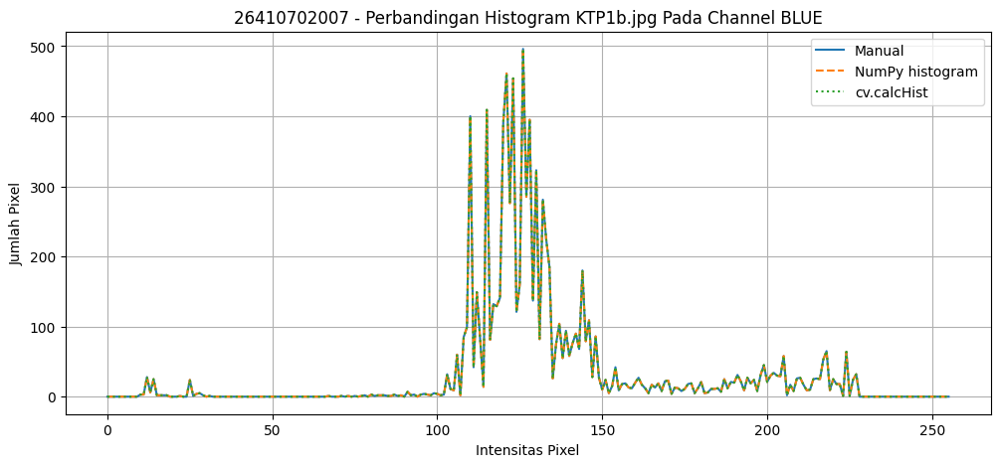

In [ ]:
# Mengambil channel B
channel = img_e1T2[:, 0, :]

# 1. Histogram menggunakan cv.calcHist
hist_cv = cv.calcHist(
    [channel],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

# 2. Histogram menggunakan numpy.histogram
hist_np, bins = np.histogram(
    channel.ravel(),
    bins=256,
    range=(0, 256)
)

# 3. Histogram manual menggunakan NumPy
hist_manual = np.zeros(256, dtype=np.int64)

for nilai in channel.ravel():
    hist_manual[nilai] += 1

# Menghitung selisih maksimum
selisih_cv_np = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_np)
)

selisih_cv_manual = np.max(
    np.abs(hist_cv.astype(np.int64) - hist_manual)
)

selisih_np_manual = np.max(
    np.abs(hist_np - hist_manual)
)

selisih_maksimum = max(
    selisih_cv_np,
    selisih_cv_manual,
    selisih_np_manual
)

print("=== HASIL PERBANDINGAN KTP1b.JPG ===")
print("Selisih maksimum cv.calcHist vs np.histogram :", selisih_cv_np)
print("Selisih maksimum cv.calcHist vs manual       :", selisih_cv_manual)
print("Selisih maksimum np.histogram vs manual      :", selisih_np_manual)
print("------------------------------------------------")
print("Selisih maksimum keseluruhan                 :", selisih_maksimum)

if selisih_maksimum == 0:
    print("✓ HASIL: Ketiga histogram SAMA PERSIS.")
else:
    print("✗ HASIL: Terdapat perbedaan pada histogram.")

# Menampilkan histogram
plt.figure(figsize=(12, 5))

plt.plot(hist_manual, label='Manual')
plt.plot(hist_np, '--', label='NumPy histogram')
plt.plot(hist_cv, ':', label='cv.calcHist')

plt.title(NIM + ' - Perbandingan Histogram KTP1b.jpg Pada Channel BLUE')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.legend()
plt.grid()
plt.show()

## **Pertanyaan Praktikum E-1.2**


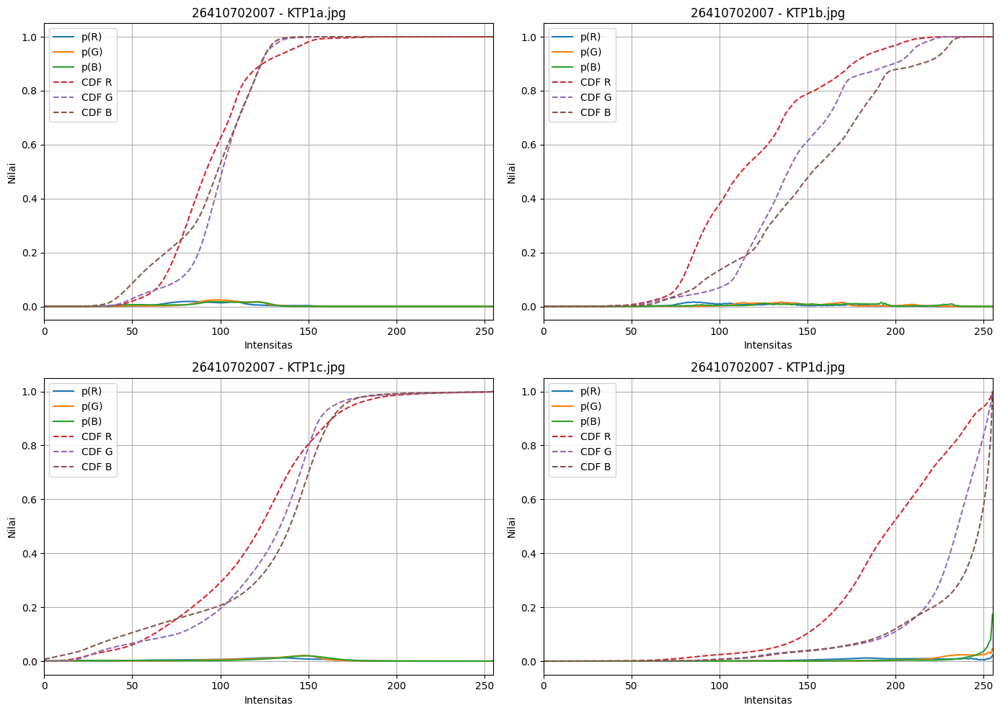

Rerata intensitas:
KTP1a.jpg -> R: 94.68 | G: 100.42 | B: 94.17
KTP1b.jpg -> R: 120.17 | G: 143.82 | B: 153.02
KTP1c.jpg -> R: 118.3 | G: 125.0 | B: 125.4
KTP1d.jpg -> R: 196.15 | G: 228.25 | B: 234.8


In [ ]:
plt.figure(figsize=(14, 10))

for idx, fname in enumerate(files, 1):

    # Membaca citra
    imge2 = cv.imread(BASE + fname)

    assert imge2 is not None, f'{fname} tidak ditemukan'

    # BGR -> RGB
    imge2 = cv.cvtColor(imge2, cv.COLOR_BGR2RGB)

    # =====================================
    # HISTOGRAM MANUAL RGB
    # =====================================

    hist_R = np.zeros(256, dtype=np.int64)
    hist_G = np.zeros(256, dtype=np.int64)
    hist_B = np.zeros(256, dtype=np.int64)

    # Histogram channel R
    for nilai in imge2[:, :, 0].ravel():
        hist_R[nilai] += 1

    # Histogram channel G
    for nilai in imge2[:, :, 1].ravel():
        hist_G[nilai] += 1

    # Histogram channel B
    for nilai in imge2[:, :, 2].ravel():
        hist_B[nilai] += 1

    # =====================================
    # PROBABILITAS
    # =====================================

    jumlah_pixel = imge2.shape[0] * imge2.shape[1]

    p_R = hist_R / jumlah_pixel
    p_G = hist_G / jumlah_pixel
    p_B = hist_B / jumlah_pixel

    # =====================================
    # CDF
    # =====================================

    cdf_R = np.cumsum(p_R)
    cdf_G = np.cumsum(p_G)
    cdf_B = np.cumsum(p_B)

    # =====================================
    # MENAMPILKAN GRAFIK
    # =====================================

    ax = plt.subplot(2, 2, idx)

    ax.plot(np.arange(256), p_R, label='p(R)')
    ax.plot(np.arange(256), p_G, label='p(G)')
    ax.plot(np.arange(256), p_B, label='p(B)')

    ax.plot(np.arange(256), cdf_R, '--', label='CDF R')
    ax.plot(np.arange(256), cdf_G, '--', label='CDF G')
    ax.plot(np.arange(256), cdf_B, '--', label='CDF B')

    ax.set_title(NIM + ' - ' + fname)
    ax.set_xlabel('Intensitas')
    ax.set_ylabel('Nilai')
    ax.set_xlim(0, 255)
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()


# =====================================
# RERATA INTENSITAS RGB
# =====================================

print('Rerata intensitas:')

for fname in files:

    imge2 = cv.imread(BASE + fname)

    assert imge2 is not None, f'{fname} tidak ditemukan'

    # BGR -> RGB
    imge2 = cv.cvtColor(imge2, cv.COLOR_BGR2RGB)

    # Rata-rata masing-masing channel
    mean_R = imge2[:, :, 0].mean()
    mean_G = imge2[:, :, 1].mean()
    mean_B = imge2[:, :, 2].mean()

    print(
        fname,
        '-> R:', round(float(mean_R), 2),
        '| G:', round(float(mean_G), 2),
        '| B:', round(float(mean_B), 2)
    )

## **Praktikum E-1.3**

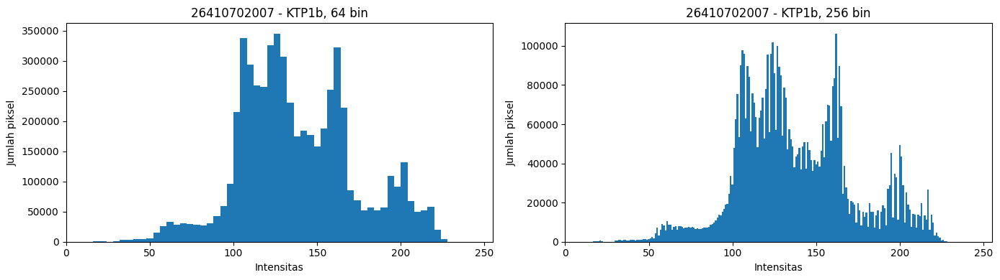

Jumlah bin personal = 64
Jumlah bin penuh = 256


In [ ]:
img_ktp1b_gray = cv.imread(BASE + files[1], cv.IMREAD_GRAYSCALE)
assert img_ktp1b_gray is not None, 'KTP1b.jpg tidak ditemukan'

# ==========================================
# HISTOGRAM MANUAL - JUMLAH BIN PERSONAL
# ==========================================

# Menyiapkan jumlah bin
jumlah_bin = PARAM['bins']

# Lebar setiap bin
lebar_bin = 256 / jumlah_bin

# Membuat histogram kosong
h_bins = np.zeros(jumlah_bin, dtype=np.int64)

# Menghitung histogram secara manual
for nilai in img_ktp1b_gray.ravel():
    indeks_bin = int(nilai / lebar_bin)

    # Jika nilai = 255, pastikan masuk bin terakhir
    # (int(255 / lebar_bin) bisa jadi jumlah_bin atau jumlah_bin - 1)
    if indeks_bin >= jumlah_bin:
        indeks_bin = jumlah_bin - 1

    h_bins[indeks_bin] += 1

# Menentukan posisi tengah setiap bin
edges = np.arange(jumlah_bin + 1) * lebar_bin
centers = (edges[:-1] + edges[1:]) / 2


# ==========================================
# HISTOGRAM MANUAL - 256 BIN
# ==========================================

h256 = np.zeros(256, dtype=np.int64)

# Setiap intensitas memiliki satu bin
for nilai in img_ktp1b_gray.ravel():
    h256[nilai] += 1


# ==========================================
# MENAMPILKAN HISTOGRAM
# ==========================================

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Histogram jumlah bin personal
ax[0].bar(
    centers,
    h_bins,
    width=lebar_bin,
    align='center'
)

ax[0].set_title(
    NIM + f" - KTP1b, {jumlah_bin} bin"
)
ax[0].set_xlabel('Intensitas')
ax[0].set_ylabel('Jumlah piksel')
ax[0].set_xlim(0, 255)


# Histogram 256 bin
ax[1].bar(
    np.arange(256),
    h256,
    width=1
)

ax[1].set_title(
    NIM + ' - KTP1b, 256 bin'
)
ax[1].set_xlabel('Intensitas')
ax[1].set_ylabel('Jumlah piksel')
ax[1].set_xlim(0, 255)

plt.tight_layout()
plt.show()


# ==========================================
# INFORMASI JUMLAH BIN
# ==========================================

print('Jumlah bin personal =', jumlah_bin)
print('Jumlah bin penuh = 256')

# E-2 PERCOBAAN HISTOGRAM EQUALIZATION

## Tahap 1. Lena_lc.jpg

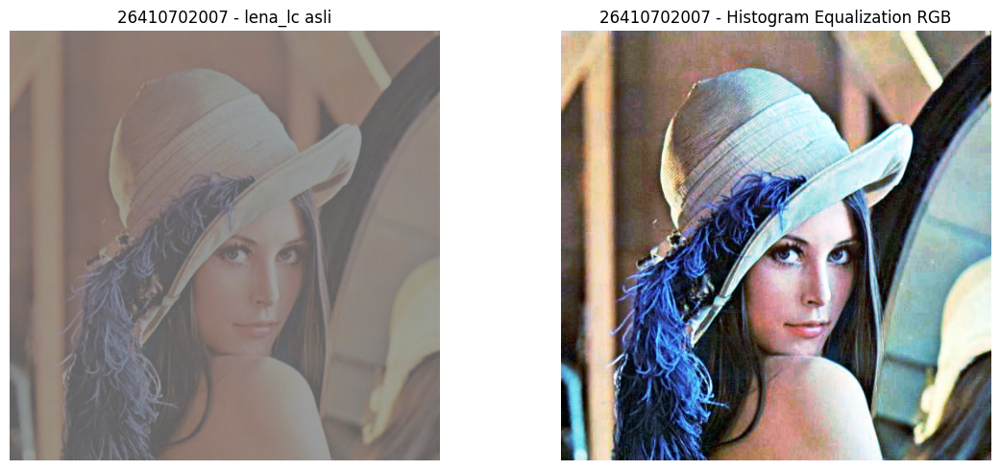

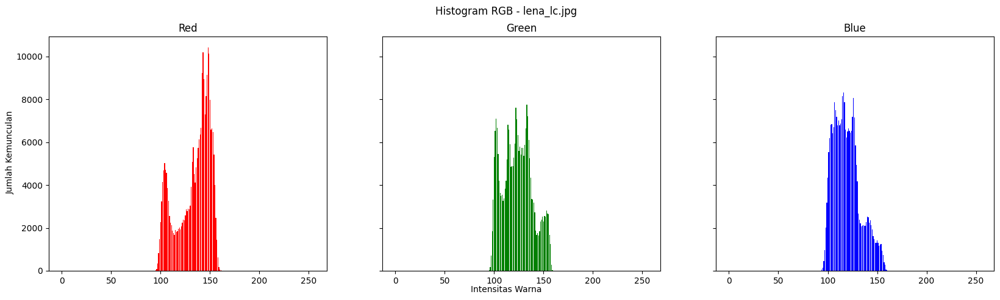

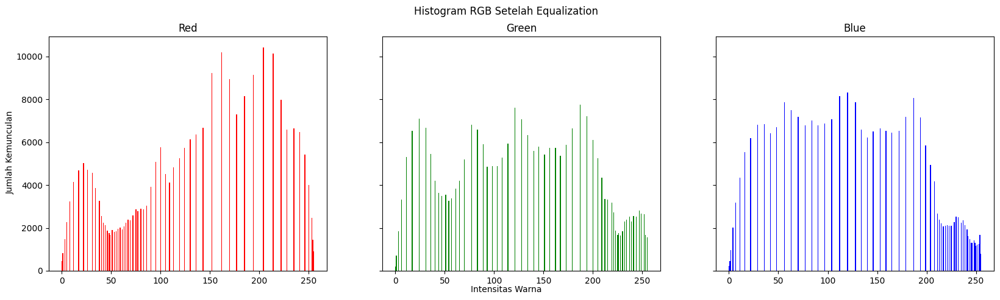

In [ ]:
# E-2.1 Tahap 1 — lena_lc.jpg

# Membaca citra
img = cv.imread(BASE + lena[1])

assert img is not None, 'lena_lc.jpg tidak ditemukan'

# BGR -> RGB
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

names = np.arange(256)

# ==========================================
# HISTOGRAM RGB MANUAL
# ==========================================

red   = [0] * 256
green = [0] * 256
blue  = [0] * 256

for y in range(0, height):
    for x in range(0, width):

        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1


# ==========================================
# CDF RGB
# ==========================================

cdf_red   = [0] * 256
cdf_green = [0] * 256
cdf_blue  = [0] * 256

cdf_red[0] = red[0]
cdf_green[0] = green[0]
cdf_blue[0] = blue[0]

for i in range(1, 256):
    cdf_red[i] = cdf_red[i-1] + red[i]
    cdf_green[i] = cdf_green[i-1] + green[i]
    cdf_blue[i] = cdf_blue[i-1] + blue[i]


# ==========================================
# CDF MINIMUM
# ==========================================

cdf_red_min = next(v for v in cdf_red if v > 0)
cdf_green_min = next(v for v in cdf_green if v > 0)
cdf_blue_min = next(v for v in cdf_blue if v > 0)


# ==========================================
# LUT HISTOGRAM EQUALIZATION
# ==========================================

lut_red = [0] * 256
lut_green = [0] * 256
lut_blue = [0] * 256

jumlah_pixel = height * width

for i in range(256):

    lut_red[i] = round(
        ((cdf_red[i] - cdf_red_min) /
         (jumlah_pixel - cdf_red_min)) * 255
    )

    lut_green[i] = round(
        ((cdf_green[i] - cdf_green_min) /
         (jumlah_pixel - cdf_green_min)) * 255
    )

    lut_blue[i] = round(
        ((cdf_blue[i] - cdf_blue_min) /
         (jumlah_pixel - cdf_blue_min)) * 255
    )


# ==========================================
# MEMBUAT CITRA HASIL EQUALIZATION
# ==========================================

he_manual = np.zeros_like(img)

for y in range(0, height):
    for x in range(0, width):

        he_manual[y][x][0] = lut_red[img[y][x][0]]
        he_manual[y][x][1] = lut_green[img[y][x][1]]
        he_manual[y][x][2] = lut_blue[img[y][x][2]]


# ==========================================
# HISTOGRAM RGB HASIL EQUALIZATION
# ==========================================

red_he   = [0] * 256
green_he = [0] * 256
blue_he  = [0] * 256

for y in range(0, height):
    for x in range(0, width):

        red_he[he_manual[y][x][0]] += 1
        green_he[he_manual[y][x][1]] += 1
        blue_he[he_manual[y][x][2]] += 1


# ==========================================
# MENAMPILKAN CITRA
# ==========================================

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(img)
ax[0].set_title(NIM + ' - lena_lc asli')
ax[0].axis('off')

ax[1].imshow(he_manual)
ax[1].set_title(NIM + ' - Histogram Equalization RGB')
ax[1].axis('off')

plt.tight_layout()
plt.show()


# ==========================================
# RGB HISTOGRAM CITRA ASLI
# ==========================================

fig, axs = plt.subplots(
    1, 3,
    figsize=[20, 5],
    sharex=True,
    sharey=True
)

fig.suptitle('Histogram RGB - lena_lc.jpg')
fig.text(
    0.09, 0.5,
    'Jumlah Kemunculan',
    va='center',
    rotation='vertical'
)
fig.text(
    0.5, 0.04,
    'Intensitas Warna',
    ha='center'
)

axs[0].bar(names, red, color='red')
axs[0].set_title('Red')

axs[1].bar(names, green, color='green')
axs[1].set_title('Green')

axs[2].bar(names, blue, color='blue')
axs[2].set_title('Blue')

plt.show()


# ==========================================
# RGB HISTOGRAM SETELAH EQUALIZATION
# ==========================================

fig, axs = plt.subplots(
    1, 3,
    figsize=[20, 5],
    sharex=True,
    sharey=True
)

fig.suptitle('Histogram RGB Setelah Equalization')
fig.text(
    0.09, 0.5,
    'Jumlah Kemunculan',
    va='center',
    rotation='vertical'
)
fig.text(
    0.5, 0.04,
    'Intensitas Warna',
    ha='center'
)

axs[0].bar(names, red_he, color='red')
axs[0].set_title('Red')

axs[1].bar(names, green_he, color='green')
axs[1].set_title('Green')

axs[2].bar(names, blue_he, color='blue')
axs[2].set_title('Blue')

plt.show()

## Tahap 2. KTP1a.jpg

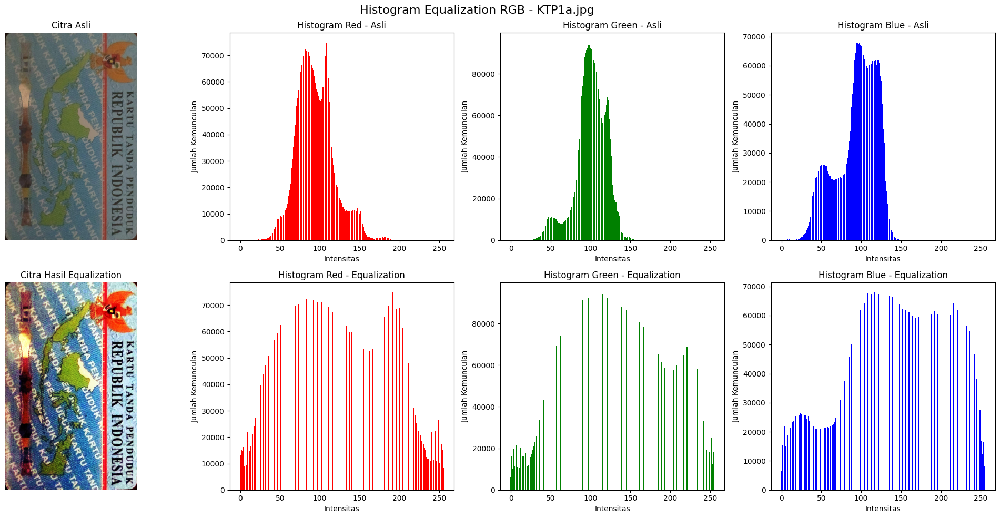

In [ ]:
# E-2.1 — Histogram Equalization files[0]

img = cv.imread(BASE + files[0])
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

# ==========================================================
# 1. Histogram RGB citra asli
# ==========================================================

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(height):
    for x in range(width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1


# ==========================================================
# 2. CDF masing-masing kanal
# ==========================================================

cdf_red = [0] * 256
cdf_green = [0] * 256
cdf_blue = [0] * 256

cdf_red[0] = red[0]
cdf_green[0] = green[0]
cdf_blue[0] = blue[0]

for i in range(1, 256):
    cdf_red[i] = cdf_red[i - 1] + red[i]
    cdf_green[i] = cdf_green[i - 1] + green[i]
    cdf_blue[i] = cdf_blue[i - 1] + blue[i]


# ==========================================================
# 3. Cari CDF minimum yang tidak nol
# ==========================================================

cdf_red_min = next(v for v in cdf_red if v > 0)
cdf_green_min = next(v for v in cdf_green if v > 0)
cdf_blue_min = next(v for v in cdf_blue if v > 0)

jumlah_pixel = height * width


# ==========================================================
# 4. Membuat LUT untuk masing-masing kanal
# ==========================================================

lut_red = [0] * 256
lut_green = [0] * 256
lut_blue = [0] * 256

for i in range(256):

    lut_red[i] = round(
        ((cdf_red[i] - cdf_red_min) /
         (jumlah_pixel - cdf_red_min)) * 255
    )

    lut_green[i] = round(
        ((cdf_green[i] - cdf_green_min) /
         (jumlah_pixel - cdf_green_min)) * 255
    )

    lut_blue[i] = round(
        ((cdf_blue[i] - cdf_blue_min) /
         (jumlah_pixel - cdf_blue_min)) * 255
    )


# ==========================================================
# 5. Membuat citra hasil equalization
# ==========================================================

he_manual = np.zeros_like(img)

for y in range(height):
    for x in range(width):

        he_manual[y][x][0] = lut_red[img[y][x][0]]
        he_manual[y][x][1] = lut_green[img[y][x][1]]
        he_manual[y][x][2] = lut_blue[img[y][x][2]]


# ==========================================================
# 6. Histogram RGB hasil equalization
# ==========================================================

red_he = [0] * 256
green_he = [0] * 256
blue_he = [0] * 256

for y in range(height):
    for x in range(width):

        red_he[he_manual[y][x][0]] += 1
        green_he[he_manual[y][x][1]] += 1
        blue_he[he_manual[y][x][2]] += 1


# ==========================================================
# 7. Menampilkan citra dan histogram
# ==========================================================

fig, ax = plt.subplots(2, 4, figsize=(20, 10))

fig.suptitle(
    'Histogram Equalization RGB - ' + files[0],
    fontsize=16
)

# Citra asli
ax[0, 0].imshow(img)
ax[0, 0].set_title('Citra Asli')
ax[0, 0].axis('off')

# Citra hasil equalization
ax[1, 0].imshow(he_manual)
ax[1, 0].set_title('Citra Hasil Equalization')
ax[1, 0].axis('off')

# Histogram asli
ax[0, 1].bar(names, red, color='red')
ax[0, 1].set_title('Histogram Red - Asli')
ax[0, 1].set_xlabel('Intensitas')
ax[0, 1].set_ylabel('Jumlah Kemunculan')

ax[0, 2].bar(names, green, color='green')
ax[0, 2].set_title('Histogram Green - Asli')
ax[0, 2].set_xlabel('Intensitas')
ax[0, 2].set_ylabel('Jumlah Kemunculan')

ax[0, 3].bar(names, blue, color='blue')
ax[0, 3].set_title('Histogram Blue - Asli')
ax[0, 3].set_xlabel('Intensitas')
ax[0, 3].set_ylabel('Jumlah Kemunculan')

# Histogram hasil equalization
ax[1, 1].bar(names, red_he, color='red')
ax[1, 1].set_title('Histogram Red - Equalization')
ax[1, 1].set_xlabel('Intensitas')
ax[1, 1].set_ylabel('Jumlah Kemunculan')

ax[1, 2].bar(names, green_he, color='green')
ax[1, 2].set_title('Histogram Green - Equalization')
ax[1, 2].set_xlabel('Intensitas')
ax[1, 2].set_ylabel('Jumlah Kemunculan')

ax[1, 3].bar(names, blue_he, color='blue')
ax[1, 3].set_title('Histogram Blue - Equalization')
ax[1, 3].set_xlabel('Intensitas')
ax[1, 3].set_ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

### Membandingkan HE manual dan cv.equalizeHist

In [26]:
# =========================================================
# LENA
# =========================================================

# Read image in grayscale
img_lena_path = BASE + lena[1]
img_lena = cv.imread(img_lena_path, cv.IMREAD_GRAYSCALE)
assert img_lena is not None, f'{lena[1]} tidak ditemukan'

# Histogram manual
hist_lena = np.bincount(img_lena.ravel(), minlength=256)

# Probabilitas
p_lena = hist_lena / img_lena.size

# CDF
cdf_lena = np.cumsum(p_lena)

# LUT manual
lut_lena = np.rint(255 * cdf_lena).astype(np.uint8)

# Histogram equalization manual
he_manual_lena = lut_lena[img_lena]

# Equalization menggunakan OpenCV
he_cv_lena = cv.equalizeHist(img_lena)

# Selisih
diff_lena = np.abs(
    he_manual_lena.astype(np.int16) -
    he_cv_lena.astype(np.int16)
)

print('lena_lc.jpg')
print('Maksimum selisih =', diff_lena.max())
print('Jumlah piksel berbeda =', np.count_nonzero(diff_lena))
print('Rerata selisih =', diff_lena.mean())


# =========================================================
# KTM1a
# =========================================================

# Read image in grayscale
img_ktm1a_path = BASE + files[0]
img_ktm1a = cv.imread(img_ktm1a_path, cv.IMREAD_GRAYSCALE)
assert img_ktm1a is not None, f'{files[0]} tidak ditemukan'

# Histogram manual
hist_ktm1a = np.bincount(img_ktm1a.ravel(), minlength=256)

# Probabilitas
p_ktm1a = hist_ktm1a / img_ktm1a.size

# CDF
cdf_ktm1a = np.cumsum(p_ktm1a)

# LUT manual
lut_ktm1a = np.rint(255 * cdf_ktm1a).astype(np.uint8)

# Histogram equalization manual
he_manual_ktm1a = lut_ktm1a[img_ktm1a]

# Equalization menggunakan OpenCV
he_cv_ktm1a = cv.equalizeHist(img_ktm1a)

# Selisih
diff_ktm1a = np.abs(
    he_manual_ktm1a.astype(np.int16) -
    he_cv_ktm1a.astype(np.int16)
)

print('KTP1a.jpg')
print('Maksimum selisih =', diff_ktm1a.max())
print('Jumlah piksel berbeda =', np.count_nonzero(diff_ktm1a))
print('Rerata selisih =', diff_ktm1a.mean())

lena_lc.jpg
Maksimum selisih = 0
Jumlah piksel berbeda = 0
Rerata selisih = 0.0
KTP1a.jpg
Maksimum selisih = 0
Jumlah piksel berbeda = 0
Rerata selisih = 0.0


### E-2.3 Ekulasi warna 5 metode

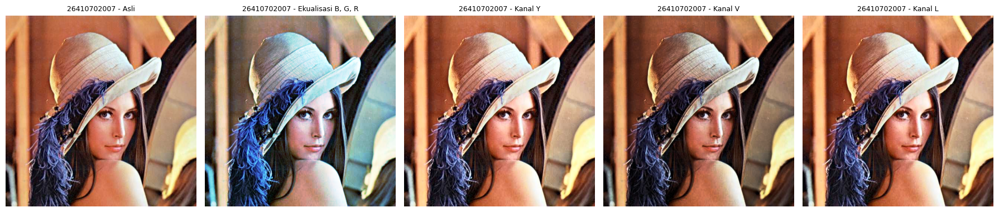

--- Hasil lena.jpg ---
Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                54.09            128.1
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.66            122.9


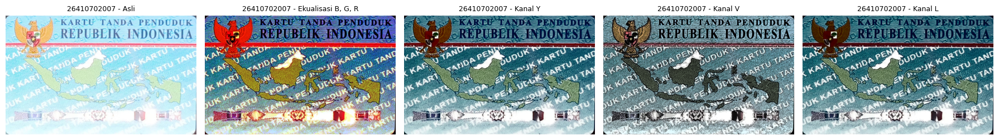


--- Hasil KTM1d.jpg ---
Cara                    geser Hue (der)    rerata terang
Asli                               0.00            219.4
Ekualisasi B, G, R                50.35            130.0
Kanal Y                            1.52            130.7
Kanal V                            2.18            124.5
Kanal L                            3.67            121.2


In [29]:
# =========================================================
# E-2.3 — EKUALISASI WARNA 5 METODE
# Manual tanpa fungsi bantu
# =========================================================


# =========================================================
# LENA.JPG
# =========================================================

bgr_lena = cv.imread(BASE + lena[0])
assert bgr_lena is not None, 'lena.jpg tidak ditemukan'


# ---------------------------------------------------------
# 1. CITRA ASLI
# ---------------------------------------------------------

asli_lena = bgr_lena.copy()


# ---------------------------------------------------------
# 2. EKUALISASI KANAL B, G, R
# ---------------------------------------------------------

b, g, r = cv.split(bgr_lena)

# Kanal B
hist_b = np.bincount(b.ravel(), minlength=256)
cdf_b = np.cumsum(hist_b / b.size)
lut_b = np.rint(255 * cdf_b).astype(np.uint8)
b_eq = lut_b[b]

# Kanal G
hist_g = np.bincount(g.ravel(), minlength=256)
cdf_g = np.cumsum(hist_g / g.size)
lut_g = np.rint(255 * cdf_g).astype(np.uint8)
g_eq = lut_g[g]

# Kanal R
hist_r = np.bincount(r.ravel(), minlength=256)
cdf_r = np.cumsum(hist_r / r.size)
lut_r = np.rint(255 * cdf_r).astype(np.uint8)
r_eq = lut_r[r]

he_bgr_lena = cv.merge([b_eq, g_eq, r_eq])


# ---------------------------------------------------------
# 3. EKUALISASI KANAL Y (YCrCb)
# ---------------------------------------------------------

ycrcb = cv.cvtColor(bgr_lena, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

hist_y = np.bincount(y.ravel(), minlength=256)
cdf_y = np.cumsum(hist_y / y.size)
lut_y = np.rint(255 * cdf_y).astype(np.uint8)
y_eq = lut_y[y]

he_y_lena = cv.cvtColor(
    cv.merge([y_eq, cr, cb]),
    cv.COLOR_YCrCb2BGR
)


# ---------------------------------------------------------
# 4. EKUALISASI KANAL V (HSV)
# ---------------------------------------------------------

hsv = cv.cvtColor(bgr_lena, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

hist_v = np.bincount(v.ravel(), minlength=256)
cdf_v = np.cumsum(hist_v / v.size)
lut_v = np.rint(255 * cdf_v).astype(np.uint8)
v_eq = lut_v[v]

he_v_lena = cv.cvtColor(
    cv.merge([h, s, v_eq]),
    cv.COLOR_HSV2BGR
)


# ---------------------------------------------------------
# 5. EKUALISASI KANAL L (LAB)
# ---------------------------------------------------------

lab = cv.cvtColor(bgr_lena, cv.COLOR_BGR2LAB)
l, a, b_lab = cv.split(lab)

hist_l = np.bincount(l.ravel(), minlength=256)
cdf_l = np.cumsum(hist_l / l.size)
lut_l = np.rint(255 * cdf_l).astype(np.uint8)
l_eq = lut_l[l]

he_l_lena = cv.cvtColor(
    cv.merge([l_eq, a, b_lab]),
    cv.COLOR_LAB2BGR
)


# =========================================================
# MENAMPILKAN HASIL LENA
# =========================================================

citra_lena = [
    asli_lena,
    he_bgr_lena,
    he_y_lena,
    he_v_lena,
    he_l_lena
]

judul_lena = [
    'Asli',
    'Ekualisasi B, G, R',
    'Kanal Y',
    'Kanal V',
    'Kanal L'
]

plt.figure(figsize=(18, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv.cvtColor(citra_lena[i], cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_lena[i], fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()


# =========================================================
# PERGESERAN HUE DAN RERATA KECERAHAN LENA
# =========================================================

hue_asli_lena = cv.cvtColor(asli_lena, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)

print('--- Hasil lena.jpg ---')
print('%-22s %16s %16s' %
      ('Cara', 'geser Hue (der)', 'rerata terang'))

for i in range(5):

    hue_hasil = cv.cvtColor(
        citra_lena[i],
        cv.COLOR_BGR2HSV
    )[:, :, 0].astype(np.int16)

    selisih_hue = np.abs(hue_asli_lena - hue_hasil)

    selisih_hue = np.minimum(
        selisih_hue,
        180 - selisih_hue
    )

    geser_hue_lena = selisih_hue.mean() * 2

    terang_lena = cv.cvtColor(
        citra_lena[i],
        cv.COLOR_BGR2GRAY
    ).mean()

    print('%-22s %16.2f %16.1f' %
          (judul_lena[i], geser_hue_lena, terang_lena))


# =========================================================
# KTM1d.JPG
# =========================================================

bgr_ktm = cv.imread(BASE + files[3])
assert bgr_ktm is not None, 'KTM1d.jpg tidak ditemukan'


# ---------------------------------------------------------
# 1. CITRA ASLI
# ---------------------------------------------------------

asli_ktm = bgr_ktm.copy()


# ---------------------------------------------------------
# 2. EKUALISASI KANAL B, G, R
# ---------------------------------------------------------

b, g, r = cv.split(bgr_ktm)

# Kanal B
hist_b = np.bincount(b.ravel(), minlength=256)
cdf_b = np.cumsum(hist_b / b.size)
lut_b = np.rint(255 * cdf_b).astype(np.uint8)
b_eq = lut_b[b]

# Kanal G
hist_g = np.bincount(g.ravel(), minlength=256)
cdf_g = np.cumsum(hist_g / g.size)
lut_g = np.rint(255 * cdf_g).astype(np.uint8)
g_eq = lut_g[g]

# Kanal R
hist_r = np.bincount(r.ravel(), minlength=256)
cdf_r = np.cumsum(hist_r / r.size)
lut_r = np.rint(255 * cdf_r).astype(np.uint8)
r_eq = lut_r[r]

he_bgr_ktm = cv.merge([b_eq, g_eq, r_eq])


# ---------------------------------------------------------
# 3. EKUALISASI KANAL Y (YCrCb)
# ---------------------------------------------------------

ycrcb = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

hist_y = np.bincount(y.ravel(), minlength=256)
cdf_y = np.cumsum(hist_y / y.size)
lut_y = np.rint(255 * cdf_y).astype(np.uint8)
y_eq = lut_y[y]

he_y_ktm = cv.cvtColor(
    cv.merge([y_eq, cr, cb]),
    cv.COLOR_YCrCb2BGR
)


# ---------------------------------------------------------
# 4. EKUALISASI KANAL V (HSV)
# ---------------------------------------------------------

hsv = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

hist_v = np.bincount(v.ravel(), minlength=256)
cdf_v = np.cumsum(hist_v / v.size)
lut_v = np.rint(255 * cdf_v).astype(np.uint8)
v_eq = lut_v[v]

he_v_ktm = cv.cvtColor(
    cv.merge([h, s, v_eq]),
    cv.COLOR_HSV2BGR
)


# ---------------------------------------------------------
# 5. EKUALISASI KANAL L (LAB)
# ---------------------------------------------------------

lab = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2LAB)
l, a, b_lab = cv.split(lab)

hist_l = np.bincount(l.ravel(), minlength=256)
cdf_l = np.cumsum(hist_l / l.size)
lut_l = np.rint(255 * cdf_l).astype(np.uint8)
l_eq = lut_l[l]

he_l_ktm = cv.cvtColor(
    cv.merge([l_eq, a, b_lab]),
    cv.COLOR_LAB2BGR
)


# =========================================================
# MENAMPILKAN HASIL KTM1d
# =========================================================

citra_ktm = [
    asli_ktm,
    he_bgr_ktm,
    he_y_ktm,
    he_v_ktm,
    he_l_ktm
]

judul_ktm = [
    'Asli',
    'Ekualisasi B, G, R',
    'Kanal Y',
    'Kanal V',
    'Kanal L'
]

plt.figure(figsize=(18, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv.cvtColor(citra_ktm[i], cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul_ktm[i], fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()


# =========================================================
# PERGESERAN HUE DAN RERATA KECERAHAN KTM1d
# =========================================================

hue_asli_ktm = cv.cvtColor(
    asli_ktm,
    cv.COLOR_BGR2HSV
)[:, :, 0].astype(np.int16)

print('\n--- Hasil KTP1d.jpg ---')
print('%-22s %16s %16s' %
      ('Cara', 'geser Hue (der)', 'rerata terang'))

for i in range(5):

    hue_hasil = cv.cvtColor(
        citra_ktm[i],
        cv.COLOR_BGR2HSV
    )[:, :, 0].astype(np.int16)

    selisih_hue = np.abs(
        hue_asli_ktm - hue_hasil
    )

    selisih_hue = np.minimum(
        selisih_hue,
        180 - selisih_hue
    )

    geser_hue_ktm = selisih_hue.mean() * 2

    terang_ktm = cv.cvtColor(
        citra_ktm[i],
        cv.COLOR_BGR2GRAY
    ).mean()

    print('%-22s %16.2f %16.1f' %
          (judul_ktm[i], geser_hue_ktm, terang_ktm))

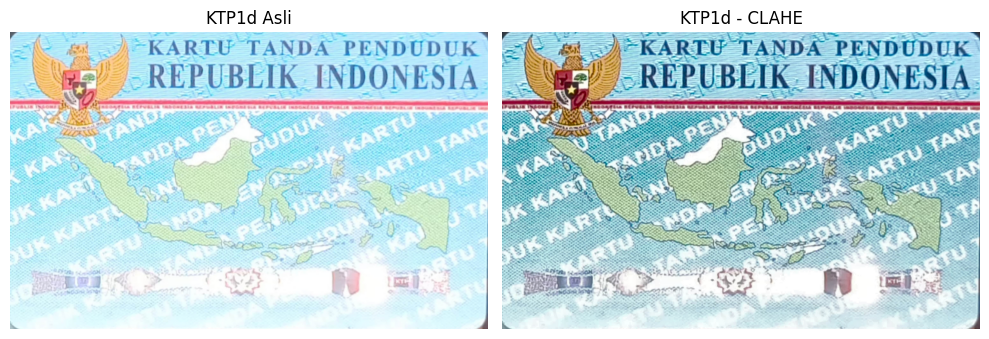

In [31]:
# =========================================================
# E-2.4 — CLAHE pada KTM1d
# =========================================================

ktm1d = cv.imread(BASE + files[3])
assert ktm1d is not None, 'KTM1d.jpg tidak ditemukan'

# Konversi BGR -> LAB
lab = cv.cvtColor(ktm1d, cv.COLOR_BGR2LAB)

# Pisahkan kanal
l, a, b = cv.split(lab)

# CLAHE
clahe = cv.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

# Terapkan CLAHE hanya pada kanal L
l_clahe = clahe.apply(l)

# Gabungkan kembali
lab_clahe = cv.merge([
    l_clahe,
    a,
    b
])

# Konversi kembali LAB -> BGR
ktm1d_clahe = cv.cvtColor(
    lab_clahe,
    cv.COLOR_LAB2BGR
)


# Tampilkan
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(ktm1d, cv.COLOR_BGR2RGB))
plt.title('KTP1d Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(ktm1d_clahe, cv.COLOR_BGR2RGB))
plt.title('KTP1d - CLAHE')
plt.axis('off')

plt.tight_layout()
plt.show()

## E-2 Pertanyaan Praktikum 1 — Global Equalization pada KTP1a

=== HASIL GLOBAL HISTOGRAM EQUALIZATION ===
MSE  = 4139.016304866808
PSNR = 11.961832236433438 dB


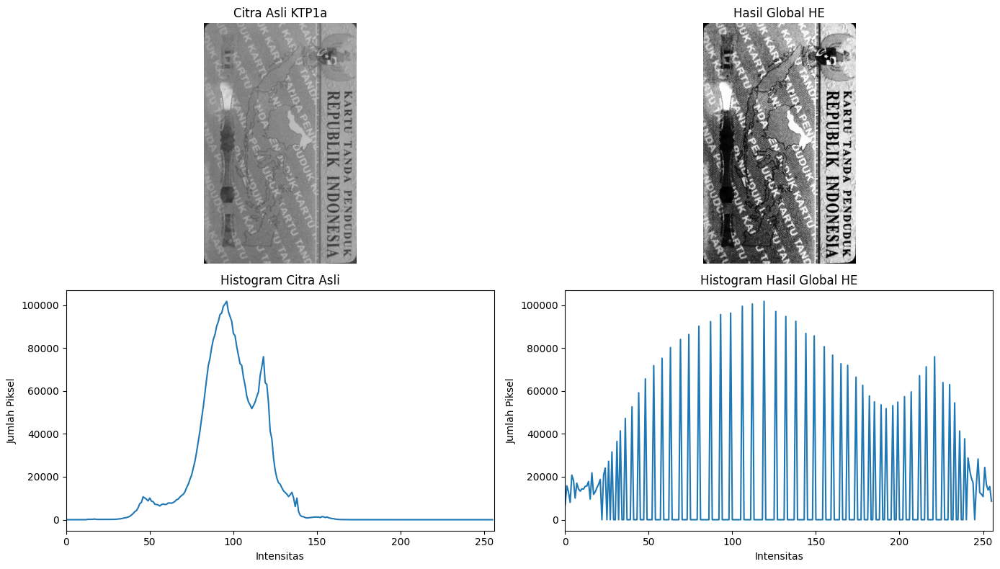

In [34]:
# Baca citra KTM1a dalam grayscale
img = cv.imread(BASE + files[0], cv.IMREAD_GRAYSCALE)
assert img is not None, 'KTM1a.jpg tidak ditemukan'

# =========================
# Global Histogram Equalization Manual
# =========================
hist = np.bincount(img.ravel(), minlength=256)
prob = hist / img.size
cdf = np.cumsum(prob)

lut = np.rint(255 * cdf).astype(np.uint8)
img_he = lut[img]

# =========================
# Histogram citra asli dan hasil HE
# =========================
hist_asli = cv.calcHist([img], [0], None, [256], [0, 256])
hist_he = cv.calcHist([img_he], [0], None, [256], [0, 256])

# =========================
# Hitung PSNR
# =========================
mse = np.mean((img.astype(np.float64) - img_he.astype(np.float64)) ** 2)

if mse == 0:
    psnr = float('inf')
else:
    psnr = 10 * np.log10((255 ** 2) / mse)

print('=== HASIL GLOBAL HISTOGRAM EQUALIZATION ===')
print('MSE  =', mse)
print('PSNR =', psnr, 'dB')

# =========================
# Tampilkan citra dan histogram
# =========================
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Citra Asli KTP1a')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_he, cmap='gray')
plt.title('Hasil Global HE')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.plot(hist_asli)
plt.title('Histogram Citra Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
plt.plot(hist_he)
plt.title('Histogram Hasil Global HE')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

## E-2 Pertanyaan 2 — CLAHE pada KTP1a

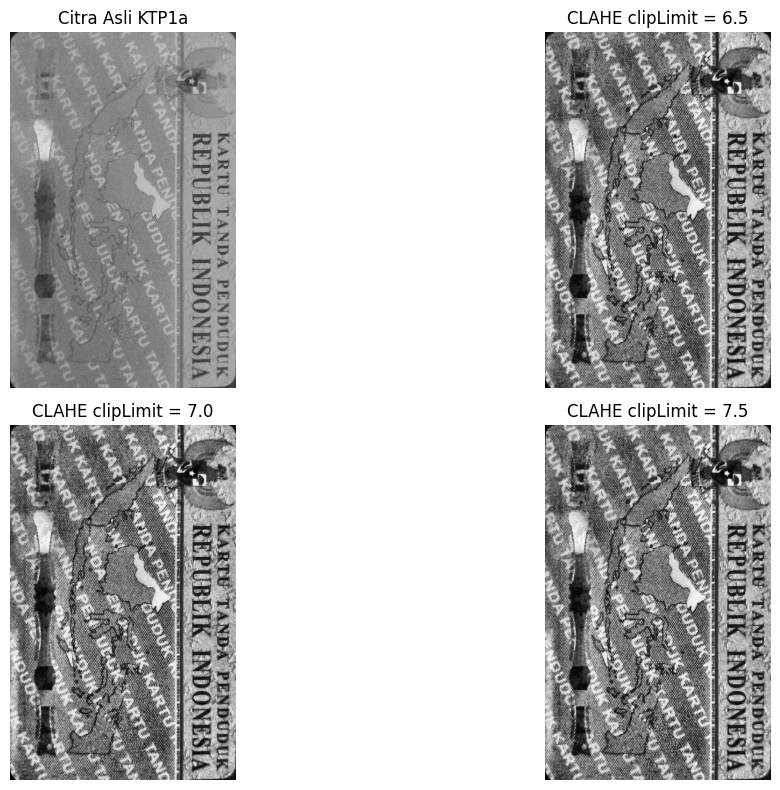

In [37]:
# Baca citra KTP1a
img = cv.imread(BASE + files[0], cv.IMREAD_GRAYSCALE)
assert img is not None, 'KTP1a.jpg tidak ditemukan'

# ==========================================
# Nilai clipLimit berdasarkan NIM
# ==========================================
clip = 7.0   # GANTI dengan nilai personal berdasarkan NIM

# Tiga nilai clipLimit
clip_values = [
    max(1.0, clip - 0.5),
    clip,
    clip + 0.5
]

# ==========================================
# Proses CLAHE
# ==========================================
hasil_clahe = []

for nilai_clip in clip_values:
    clahe = cv.createCLAHE(
        clipLimit=nilai_clip,
        tileGridSize=(8, 8)
    )

    hasil = clahe.apply(img)
    hasil_clahe.append(hasil)

# ==========================================
# Tampilkan citra asli dan hasil CLAHE
# ==========================================
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Citra Asli KTP1a')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(hasil_clahe[0], cmap='gray')
plt.title(f'CLAHE clipLimit = {clip_values[0]}')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(hasil_clahe[1], cmap='gray')
plt.title(f'CLAHE clipLimit = {clip_values[1]}')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(hasil_clahe[2], cmap='gray')
plt.title(f'CLAHE clipLimit = {clip_values[2]}')
plt.axis('off')

plt.tight_layout()
plt.show()

# E-3 — Tugas Praktikum Dithering
## E-3.1 Floyd–Steinberg pada `lena.jpg`

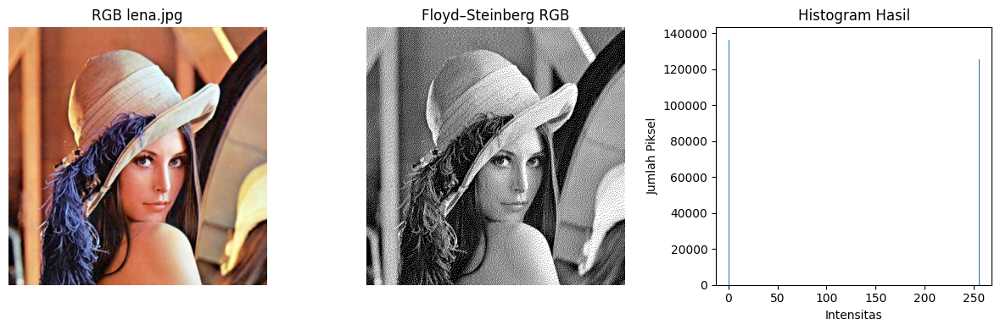

In [51]:
# Membaca citra lena.jpg
lena = cv.imread(BASE + 'lena.jpg')

assert lena is not None, 'lena.jpg tidak ditemukan'

# Konversi BGR ke RGB
lena_rgb = cv.cvtColor(lena, cv.COLOR_BGR2RGB)

# Konversi grayscale untuk proses Floyd-Steinberg
lena_gray = cv.cvtColor(lena, cv.COLOR_BGR2GRAY)

# Salin citra grayscale ke float
lena_fs = lena_gray.astype(np.float32).copy()

tinggi, lebar = lena_fs.shape

# Proses Floyd-Steinberg
for y in range(tinggi):
    for x in range(lebar):

        nilai_lama = lena_fs[y, x]

        # Kuantisasi menjadi 0 atau 255
        if nilai_lama < 128:
            nilai_baru = 0
        else:
            nilai_baru = 255

        lena_fs[y, x] = nilai_baru

        # Hitung error
        error = nilai_lama - nilai_baru

        # Distribusi error
        if x + 1 < lebar:
            lena_fs[y, x + 1] += error * 7 / 16

        if y + 1 < tinggi and x - 1 >= 0:
            lena_fs[y + 1, x - 1] += error * 3 / 16

        if y + 1 < tinggi:
            lena_fs[y + 1, x] += error * 5 / 16

        if y + 1 < tinggi and x + 1 < lebar:
            lena_fs[y + 1, x + 1] += error * 1 / 16

# Batasi nilai piksel
lena_fs = np.clip(lena_fs, 0, 255).astype(np.uint8)

# Ubah hasil Floyd-Steinberg grayscale menjadi RGB
lena_fs_rgb = cv.cvtColor(lena_fs, cv.COLOR_GRAY2RGB)

# Menampilkan hasil
plt.figure(figsize=(12, 4))

# Gambar pertama: RGB asli
plt.subplot(1, 3, 1)
plt.imshow(lena_rgb)
plt.title('RGB lena.jpg')
plt.axis('off')

# Gambar kedua: hasil Floyd-Steinberg dalam RGB
plt.subplot(1, 3, 2)
plt.imshow(lena_fs_rgb)
plt.title('Floyd–Steinberg RGB')
plt.axis('off')

# Histogram hasil
plt.subplot(1, 3, 3)
plt.hist(lena_fs.ravel(), bins=256, range=[0, 256])
plt.title('Histogram Hasil')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

## E-3.1 Floyd–Steinberg pada `KPT1b.jpg`

Nilai PARAM['L'] = 4


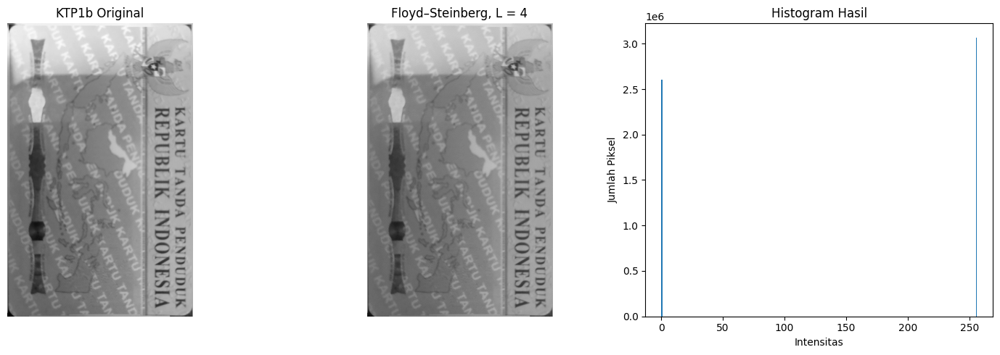

In [52]:
# Tahap 2: Floyd–Steinberg pada KTP1b.jpg

# Baca gambar KTP1b
ktp1b = cv.imread(BASE + files[1], cv.IMREAD_GRAYSCALE)
assert ktp1b is not None, 'KTP1b.jpg tidak ditemukan'

# Ambil parameter L
L = PARAM['L']

# Salin gambar ke float agar error difusi dapat dihitung
ktp1b_fs = ktp1b.astype(np.float32).copy()

tinggi, lebar = ktp1b_fs.shape

# Proses Floyd–Steinberg
for y in range(tinggi):
    for x in range(lebar):

        nilai_lama = ktp1b_fs[y, x]

        # Menggunakan PARAM['L'] sebagai nilai ambang
        if nilai_lama < L:
            nilai_baru = 0
        else:
            nilai_baru = 255

        ktp1b_fs[y, x] = nilai_baru

        # Hitung error kuantisasi
        error = nilai_lama - nilai_baru

        # Sebarkan error ke piksel tetangga
        if x + 1 < lebar:
            ktp1b_fs[y, x + 1] += error * 7 / 16

        if y + 1 < tinggi and x - 1 >= 0:
            ktp1b_fs[y + 1, x - 1] += error * 3 / 16

        if y + 1 < tinggi:
            ktp1b_fs[y + 1, x] += error * 5 / 16

        if y + 1 < tinggi and x + 1 < lebar:
            ktp1b_fs[y + 1, x + 1] += error * 1 / 16

# Batasi nilai dan ubah kembali ke uint8
ktp1b_fs = np.clip(ktp1b_fs, 0, 255).astype(np.uint8)

print("Nilai PARAM['L'] =", L)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(ktp1b, cmap='gray')
plt.title('KTP1b Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(ktp1b_fs, cmap='gray')
plt.title("Floyd–Steinberg, L = " + str(L))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.hist(ktp1b_fs.ravel(), bins=256, range=(0, 256))
plt.title('Histogram Hasil')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

## E-3.2 — Histogram Equalization → Floyd–Steinberg

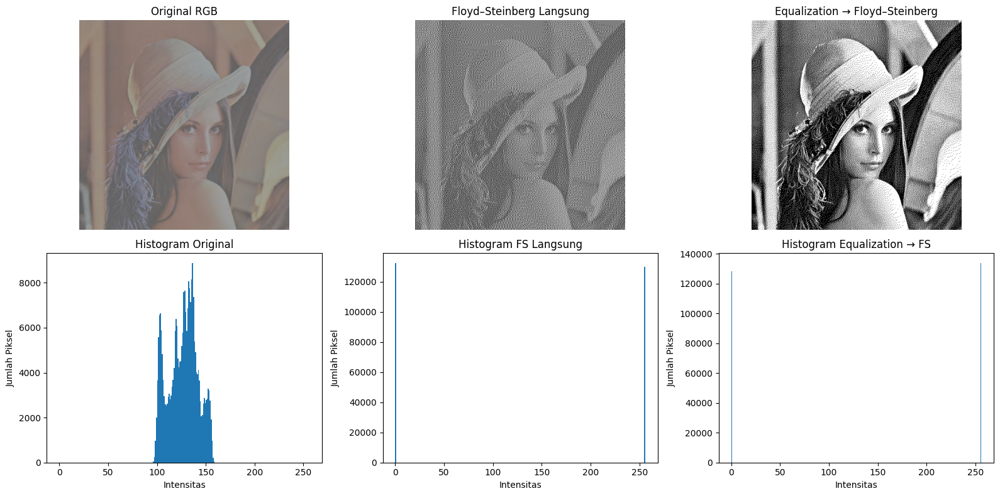

In [53]:
# ============================================================
# E-3.2 — Histogram Equalization → Floyd–Steinberg
# Tahap 1: lena_lc.jpg
# ============================================================

# Membaca citra
lena_lc = cv.imread(BASE + 'lena_lc.jpg')

assert lena_lc is not None, 'lena_lc.jpg tidak ditemukan'

# Konversi BGR ke RGB untuk tampilan
lena_lc_rgb = cv.cvtColor(lena_lc, cv.COLOR_BGR2RGB)

# Konversi ke grayscale untuk pengolahan
lena_lc_gray = cv.cvtColor(lena_lc, cv.COLOR_BGR2GRAY)


# ============================================================
# A. Floyd–Steinberg LANGSUNG tanpa Equalization
# ============================================================

lena_lc_fs = lena_lc_gray.astype(np.float32).copy()

tinggi, lebar = lena_lc_fs.shape

for y in range(tinggi):
    for x in range(lebar):

        nilai_lama = lena_lc_fs[y, x]

        if nilai_lama < 128:
            nilai_baru = 0
        else:
            nilai_baru = 255

        lena_lc_fs[y, x] = nilai_baru

        error = nilai_lama - nilai_baru

        if x + 1 < lebar:
            lena_lc_fs[y, x + 1] += error * 7 / 16

        if y + 1 < tinggi and x - 1 >= 0:
            lena_lc_fs[y + 1, x - 1] += error * 3 / 16

        if y + 1 < tinggi:
            lena_lc_fs[y + 1, x] += error * 5 / 16

        if y + 1 < tinggi and x + 1 < lebar:
            lena_lc_fs[y + 1, x + 1] += error * 1 / 16

lena_lc_fs = np.clip(lena_lc_fs, 0, 255).astype(np.uint8)

# Ubah hasil menjadi RGB
lena_lc_fs_rgb = cv.cvtColor(lena_lc_fs, cv.COLOR_GRAY2RGB)


# ============================================================
# B. Histogram Equalization
# ============================================================

hist = np.bincount(lena_lc_gray.ravel(), minlength=256)

prob = hist / lena_lc_gray.size

cdf = np.cumsum(prob)

lut = np.rint(255 * cdf).astype(np.uint8)

lena_lc_he = lut[lena_lc_gray]


# ============================================================
# C. Floyd–Steinberg setelah Histogram Equalization
# ============================================================

lena_lc_he_fs = lena_lc_he.astype(np.float32).copy()

tinggi, lebar = lena_lc_he_fs.shape

for y in range(tinggi):
    for x in range(lebar):

        nilai_lama = lena_lc_he_fs[y, x]

        if nilai_lama < 128:
            nilai_baru = 0
        else:
            nilai_baru = 255

        lena_lc_he_fs[y, x] = nilai_baru

        error = nilai_lama - nilai_baru

        if x + 1 < lebar:
            lena_lc_he_fs[y, x + 1] += error * 7 / 16

        if y + 1 < tinggi and x - 1 >= 0:
            lena_lc_he_fs[y + 1, x - 1] += error * 3 / 16

        if y + 1 < tinggi:
            lena_lc_he_fs[y + 1, x] += error * 5 / 16

        if y + 1 < tinggi and x + 1 < lebar:
            lena_lc_he_fs[y + 1, x + 1] += error * 1 / 16

lena_lc_he_fs = np.clip(lena_lc_he_fs, 0, 255).astype(np.uint8)

# Ubah hasil menjadi RGB
lena_lc_he_fs_rgb = cv.cvtColor(lena_lc_he_fs, cv.COLOR_GRAY2RGB)


# ============================================================
# D. Menampilkan Perbandingan
# ============================================================

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(lena_lc_rgb)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(lena_lc_fs_rgb)
plt.title('Floyd–Steinberg Langsung')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(lena_lc_he_fs_rgb)
plt.title('Equalization → Floyd–Steinberg')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(lena_lc_gray.ravel(), bins=256, range=[0, 256])
plt.title('Histogram Original')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.subplot(2, 3, 5)
plt.hist(lena_lc_fs.ravel(), bins=256, range=[0, 256])
plt.title('Histogram FS Langsung')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.subplot(2, 3, 6)
plt.hist(lena_lc_he_fs.ravel(), bins=256, range=[0, 256])
plt.title('Histogram Equalization → FS')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

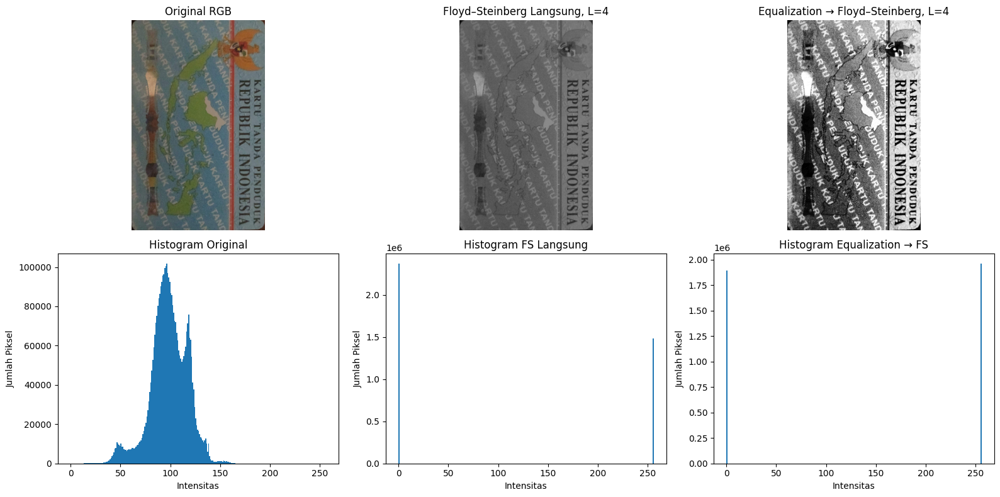

In [54]:
# ============================================================
# Tahap 2: KTP1a.jpg
# ============================================================

# Membaca citra
ktp1a = cv.imread(BASE + 'KTP1a.jpg')

assert ktp1a is not None, 'KTP1a.jpg tidak ditemukan'

# RGB untuk tampilan
ktp1a_rgb = cv.cvtColor(ktp1a, cv.COLOR_BGR2RGB)

# Grayscale untuk pengolahan
ktp1a_gray = cv.cvtColor(ktp1a, cv.COLOR_BGR2GRAY)

# Nilai threshold menggunakan PARAM['L']
L = PARAM['L']


# ============================================================
# A. Floyd–Steinberg LANGSUNG
# ============================================================

ktp1a_fs = ktp1a_gray.astype(np.float32).copy()

tinggi, lebar = ktp1a_fs.shape

for y in range(tinggi):
    for x in range(lebar):

        nilai_lama = ktp1a_fs[y, x]

        if nilai_lama < L:
            nilai_baru = 0
        else:
            nilai_baru = 255

        ktp1a_fs[y, x] = nilai_baru

        error = nilai_lama - nilai_baru

        if x + 1 < lebar:
            ktp1a_fs[y, x + 1] += error * 7 / 16

        if y + 1 < tinggi and x - 1 >= 0:
            ktp1a_fs[y + 1, x - 1] += error * 3 / 16

        if y + 1 < tinggi:
            ktp1a_fs[y + 1, x] += error * 5 / 16

        if y + 1 < tinggi and x + 1 < lebar:
            ktp1a_fs[y + 1, x + 1] += error * 1 / 16

ktp1a_fs = np.clip(ktp1a_fs, 0, 255).astype(np.uint8)

# Hasil dibuat RGB
ktp1a_fs_rgb = cv.cvtColor(ktp1a_fs, cv.COLOR_GRAY2RGB)


# ============================================================
# B. Histogram Equalization
# ============================================================

hist = np.bincount(ktp1a_gray.ravel(), minlength=256)

prob = hist / ktp1a_gray.size

cdf = np.cumsum(prob)

lut = np.rint(255 * cdf).astype(np.uint8)

ktp1a_he = lut[ktp1a_gray]


# ============================================================
# C. Floyd–Steinberg setelah Equalization
# ============================================================

ktp1a_he_fs = ktp1a_he.astype(np.float32).copy()

tinggi, lebar = ktp1a_he_fs.shape

for y in range(tinggi):
    for x in range(lebar):

        nilai_lama = ktp1a_he_fs[y, x]

        if nilai_lama < L:
            nilai_baru = 0
        else:
            nilai_baru = 255

        ktp1a_he_fs[y, x] = nilai_baru

        error = nilai_lama - nilai_baru

        if x + 1 < lebar:
            ktp1a_he_fs[y, x + 1] += error * 7 / 16

        if y + 1 < tinggi and x - 1 >= 0:
            ktp1a_he_fs[y + 1, x - 1] += error * 3 / 16

        if y + 1 < tinggi:
            ktp1a_he_fs[y + 1, x] += error * 5 / 16

        if y + 1 < tinggi and x + 1 < lebar:
            ktp1a_he_fs[y + 1, x + 1] += error * 1 / 16

ktp1a_he_fs = np.clip(ktp1a_he_fs, 0, 255).astype(np.uint8)

# Hasil dibuat RGB
ktp1a_he_fs_rgb = cv.cvtColor(ktp1a_he_fs, cv.COLOR_GRAY2RGB)


# ============================================================
# D. Menampilkan Perbandingan
# ============================================================

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(ktp1a_rgb)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(ktp1a_fs_rgb)
plt.title("Floyd–Steinberg Langsung, L=" + str(L))
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(ktp1a_he_fs_rgb)
plt.title("Equalization → Floyd–Steinberg, L=" + str(L))
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(ktp1a_gray.ravel(), bins=256, range=[0, 256])
plt.title('Histogram Original')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.subplot(2, 3, 5)
plt.hist(ktp1a_fs.ravel(), bins=256, range=[0, 256])
plt.title('Histogram FS Langsung')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.subplot(2, 3, 6)
plt.hist(ktp1a_he_fs.ravel(), bins=256, range=[0, 256])
plt.title('Histogram Equalization → FS')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

### VERIFIKASI MANUAL

In [55]:
# Verifikasi Manual Satu Langkah Floyd–Steinberg pada KTP1a

import cv2 as cv
import numpy as np

# Baca citra KTP dalam grayscale
ktp1a = cv.imread(BASE + 'KTP1a.jpg', cv.IMREAD_GRAYSCALE)
assert ktp1a is not None, 'KTP1a.jpg tidak ditemukan'

# Step untuk citra biner
step = 255

# Pilih satu piksel interior
# Pastikan bukan piksel di tepi agar keempat tetangga tersedia
y = ktp1a.shape[0] // 2
x = ktp1a.shape[1] // 2

# Nilai piksel sebelum dithering
lama = float(ktp1a[y, x])

# =========================================================
# PERHITUNGAN MANUAL
# =========================================================

baru_manual = round(lama / step) * step
error_manual = lama - baru_manual

kanan_manual = ktp1a[y, x + 1] + (7 / 16) * error_manual
kiri_bawah_manual = ktp1a[y + 1, x - 1] + (3 / 16) * error_manual
bawah_manual = ktp1a[y + 1, x] + (5 / 16) * error_manual
kanan_bawah_manual = ktp1a[y + 1, x + 1] + (1 / 16) * error_manual

# =========================================================
# PERHITUNGAN PROGRAM
# =========================================================

ktp_work = ktp1a.astype(np.float32).copy()

lama_program = ktp_work[y, x]

baru_program = round(float(lama_program) / step) * step
error_program = lama_program - baru_program

ktp_work[y, x] = baru_program

ktp_work[y, x + 1] += (7 / 16) * error_program
ktp_work[y + 1, x - 1] += (3 / 16) * error_program
ktp_work[y + 1, x] += (5 / 16) * error_program
ktp_work[y + 1, x + 1] += (1 / 16) * error_program

# =========================================================
# HASIL VERIFIKASI
# =========================================================

print('=== VERIFIKASI MANUAL SATU LANGKAH FLOYD–STEINBERG ===')
print('Koordinat piksel :', '(y, x) =', (y, x))
print('Step             :', step)
print()

print('Nilai lama       :', lama)
print('Nilai baru       :', baru_manual)
print('Error            :', error_manual)
print()

print('                 Manual       Program')
print('Kanan            :', kanan_manual,      ktp_work[y, x + 1])
print('Kiri-bawah       :', kiri_bawah_manual, ktp_work[y + 1, x - 1])
print('Bawah            :', bawah_manual,      ktp_work[y + 1, x])
print('Kanan-bawah      :', kanan_bawah_manual, ktp_work[y + 1, x + 1])
print()

print('Selisih kanan       :', abs(kanan_manual - ktp_work[y, x + 1]))
print('Selisih kiri-bawah  :', abs(kiri_bawah_manual - ktp_work[y + 1, x - 1]))
print('Selisih bawah       :', abs(bawah_manual - ktp_work[y + 1, x]))
print('Selisih kanan-bawah :', abs(kanan_bawah_manual - ktp_work[y + 1, x + 1]))

=== VERIFIKASI MANUAL SATU LANGKAH FLOYD–STEINBERG ===
Koordinat piksel : (y, x) = (1232, 782)
Step             : 255

Nilai lama       : 94.0
Nilai baru       : 0
Error            : 94.0

                 Manual       Program
Kanan            : 137.125 137.125
Kiri-bawah       : 104.625 104.625
Bawah            : 121.375 121.375
Kanan-bawah      : 100.875 100.875

Selisih kanan       : 0.0
Selisih kiri-bawah  : 0.0
Selisih bawah       : 0.0
Selisih kanan-bawah : 0.0
